# Стилометрия

Сегодня мы научимся применять метод Дельты Бёрроза (Burrow's Delta) к коллекции текстов для определения авторства спорного текста. Будем тренироваться на [корпусе](https://drive.google.com/file/d/1TnJ9t2zRLten0OoHS5axgyIXgujVLejH/view?usp=sharing), собранном по мотивам датасета galbraith_data из библиотеки [stylo](https://github.com/computationalstylistics/stylo) языка R. В корпус включены тексты авторов фэнтези-циклов Толкина и Льюиса, романы Роулинг, а также тексты автора детективов Кобена. Texts in question - детективы, написанные под пседвонимом Галбрайт. То есть если авторский сигнал окажется сильнее жанрового, это будет дополнительным подтверждении гипотезы о том, что под этим пседвоними пишет Роулинг.

> [Тут](https://publications.hse.ru/pubs/share/direct/950068199.pdf) можно прочитать статью о том, действительно ли дельта Бёрроуза доказывает, что автор детективов Галбрайт - это Дж. К. Роулинг.

> [Тут](https://pushkinskijdom.ru/zhurnal-russkaya-literatura/zhurnal-russkaya-literatura-2022-1/utochnennaya-tsifrovaya-tekstologiya-eshhe-raz-k-voprosu-ob-avtorstve-romana-tihij-don/) - знаменитый кейс с авторством "Тихого Дона".

______________________________
_Cогласно требованиям филологической критики, отвержение авторства должно быть основано на данных рукописной традиции, свидетельствах современников, соответствии бытовых и исторических реалий времени жизни автора, а также на соответствии идей, тем и жанров тому, что известно по подлинным сочинениям автора. Стилистические и языковые особенности — лишь один, не главный и не единственный, инструмент исследователя, а из этих особенностей лишь некоторые могут быть описаны количественно._

Алиева О. В. Pseudoplatonica: блеск и нищета стилометрии // Философия. Журнал Высшей школы экономики. — 2024. — Т. 8, No 3. — С. 35–56.
_________________

In [ ]:
#!pip install numpy pandas matplotlib seaborn scikit-learn nltk

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances
import numpy as np
from collections import Counter
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

[nltk_data] Downloading package stopwords to /Users/darya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Подготовка корпуса

Загрузим файлы .txt из архива .zip.

In [5]:
!unzip -q galbraith.zip

In [68]:
def load_texts_from_folder(folder_path):
    """Загружает тексты из указанной папки"""
    texts = {}
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            with open(os.path.join(folder_path, filename), 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
                texts[f"{filename.replace('.txt', '')}"] = text
    return texts

texts = load_texts_from_folder("galbraith")

Оставим только слова и приведём к нижнему регистру.

In [69]:
def preprocess_en(texts):
    for title, text in texts.items():
        text = re.sub(r"\n", " ", text)
        text = re.sub(r"[^A-Za-z\s\-]", "", text)
        text = re.sub(r"\s+", " ", text)
        texts[title] = text.lower().strip()
    return texts

texts = preprocess_en(texts)

In [70]:
texts["breaker_coben"]

'harlan coben deal breaker by this like everything else is for anne acknowledgement the author wishes to thank sunandan b singh md chief medical examiner of bergen county new jersey bob richter rich henshaw richard curtis jacob hoye shawn coyne and of course dave bolt otto burke wizard of schmooze raised his game another level come on myron he urged with neoreligious fervor im sure we can come to an understanding here you give a little we give a little the titans are a team in some larger sense i would like all of us to be a team you included lets be a real team myron what do you say myron bolitar steepled his fingers he had read somewhere that steepled fingers made you look like a thoughtful person he felt foolish id like nothing more otto he said returning the pointless volley for the umpteenth time really i would but weve given as much as we can its your turn now otto nodded vigorously as if he had just heard some philosophical whimsy that put socrates to shame he tilted his head an

Выберем только 100 самых частотных слов и векторизуем по ним тексты.

In [71]:
vectorizer = CountVectorizer(max_features=100)
sparce_matrix = vectorizer.fit_transform(texts.values())
print(sparce_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2623 stored elements and shape (27, 100)>
  Coords	Values
  (0, 65)	658
  (0, 13)	611
  (0, 90)	521
  (0, 0)	337
  (0, 91)	252
  (0, 87)	355
  (0, 5)	124
  (0, 95)	44
  (0, 98)	1141
  (0, 47)	709
  (0, 76)	212
  (0, 25)	110
  (0, 56)	658
  (0, 6)	267
  (0, 78)	314
  (0, 46)	205
  (0, 60)	365
  (0, 7)	518
  (0, 73)	4023
  (0, 37)	1050
  (0, 4)	1649
  (0, 35)	192
  (0, 54)	1059
  (0, 45)	72
  (0, 82)	247
  :	:
  (26, 32)	125
  (26, 99)	206
  (26, 34)	1490
  (26, 42)	192
  (26, 33)	728
  (26, 97)	176
  (26, 8)	134
  (26, 81)	102
  (26, 66)	227
  (26, 2)	394
  (26, 23)	379
  (26, 20)	178
  (26, 79)	152
  (26, 48)	154
  (26, 71)	124
  (26, 26)	217
  (26, 52)	279
  (26, 1)	217
  (26, 88)	186
  (26, 61)	222
  (26, 85)	280
  (26, 15)	94
  (26, 70)	2
  (26, 28)	1868
  (26, 64)	720


Что хранится в матрице?
| Coords  | Values |
| ------------- | ------------- |
| (0, 381)  | 26 |

Это значит, что в документе №0 слово №381 встречается 26 раз.

Нам бы интереснее было увидеть это в виде не разреженной, а плотной матрицы (то есть обычного numpy массива):

In [72]:
dense_matrix = sparce_matrix.toarray()
dense_matrix

array([[ 337,  173,  291, ...,  245, 1141,  209],
       [ 183,   56,  371, ...,  148,  630,  133],
       [ 458,  191,  541, ...,  324, 1739,  269],
       ...,
       [ 479,  210,  403, ...,  310, 1426,  191],
       [ 116,   57,  337, ...,  100,  455,   79],
       [ 252,  217,  394, ...,  176, 1196,  206]], shape=(27, 100))

In [91]:
freq_df = pd.DataFrame(dense_matrix, 
                       index=texts.keys(), # строки -- этот названия текстов
                       # колонки -- это слова, по которым векторизовали
                       columns=vectorizer.get_feature_names_out()) 
freq_df = freq_df.astype(float)
total_words = {name: len(text.split()) for name, text in texts.items()}
for name in freq_df.index:
    freq_df.loc[name] = freq_df.loc[name] / total_words[name]
freq_df.head()

,about,again,all,an,and,are,as,at,away,back,...,what,when,where,which,who,will,with,would,you,your
tellnoone_coben,0.004032,0.002070,0.003482,0.002249,0.019729,0.001484,0.003194,0.006197,0.001376,0.003422,...,0.006233,0.003015,0.001292,0.000239,0.001531,0.000526,0.006568,0.002931,0.013651,0.002500
narnia_4_lewis,0.003550,0.001086,0.007196,0.001901,0.037883,0.002405,0.007778,0.006595,0.001435,0.001940,...,0.003589,0.003608,0.001203,0.002716,0.002037,0.001571,0.005334,0.002871,0.012220,0.002580
cuckoo_ galbraith,0.003010,0.001255,0.003556,0.003352,0.024074,0.000953,0.005389,0.005816,0.000979,0.002721,...,0.003404,0.002701,0.001249,0.001761,0.002603,0.000526,0.007854,0.002129,0.011429,0.001768
hobbit_tolkien,0.002268,0.002016,0.006971,0.001312,0.047351,0.003286,0.007307,0.006971,0.001417,0.002320,...,0.003108,0.002856,0.001659,0.001869,0.001396,0.002110,0.006856,0.002604,0.008683,0.002142
lord_2_lewis,0.002615,0.001795,0.007979,0.001884,0.040403,0.003147,0.007137,0.007558,0.001152,0.001995,...,0.003613,0.003435,0.001551,0.002105,0.002726,0.001662,0.006383,0.002682,0.011569,0.003613


In [89]:
# Обернём всё это в функцию
def vectorize(texts, max_features=100):
    vectorizer = CountVectorizer(max_features=max_features)
    sparce_matrix = vectorizer.fit_transform(texts.values())
    dense_matrix = sparce_matrix.toarray()

    freq_df = pd.DataFrame(dense_matrix, 
                       index=texts.keys(), 
                       columns=vectorizer.get_feature_names_out()) 
    freq_df = freq_df.astype(float)
    total_words = {name: len(text.split()) for name, text in texts.items()}
    for name in freq_df.index:
            freq_df.loc[name] = freq_df.loc[name] / total_words[name]
    
    return freq_df

freq_df = vectorize(texts)
freq_df

,about,again,all,an,and,are,as,at,away,back,...,what,when,where,which,who,will,with,would,you,your
tellnoone_coben,0.004032,0.002070,0.003482,0.002249,0.019729,0.001484,0.003194,0.006197,0.001376,0.003422,...,0.006233,0.003015,0.001292,0.000239,0.001531,0.000526,0.006568,0.002931,0.013651,0.002500
narnia_4_lewis,0.003550,0.001086,0.007196,0.001901,0.037883,0.002405,0.007778,0.006595,0.001435,0.001940,...,0.003589,0.003608,0.001203,0.002716,0.002037,0.001571,0.005334,0.002871,0.012220,0.002580
cuckoo_ galbraith,0.003010,0.001255,0.003556,0.003352,0.024074,0.000953,0.005389,0.005816,0.000979,0.002721,...,0.003404,0.002701,0.001249,0.001761,0.002603,0.000526,0.007854,0.002129,0.011429,0.001768
hobbit_tolkien,0.002268,0.002016,0.006971,0.001312,0.047351,0.003286,0.007307,0.006971,0.001417,0.002320,...,0.003108,0.002856,0.001659,0.001869,0.001396,0.002110,0.006856,0.002604,0.008683,0.002142
lord_2_lewis,0.002615,0.001795,0.007979,0.001884,0.040403,0.003147,0.007137,0.007558,0.001152,0.001995,...,0.003613,0.003435,0.001551,0.002105,0.002726,0.001662,0.006383,0.002682,0.011569,0.003613
hp_1_rowling,0.002967,0.001109,0.004798,0.002860,0.025139,0.001938,0.006856,0.008032,0.000842,0.003301,...,0.003916,0.002152,0.001203,0.001136,0.002339,0.001163,0.005506,0.001443,0.010545,0.001898
child_rowling,0.002632,0.001536,0.004102,0.001821,0.027092,0.005528,0.004607,0.007744,0.001294,0.002940,...,0.005638,0.001579,0.001294,0.001031,0.001821,0.002567,0.005375,0.001009,0.023407,0.004804
narnia_5_lewis,0.003162,0.001426,0.006386,0.001447,0.041190,0.002873,0.007564,0.007316,0.001633,0.002067,...,0.003927,0.003286,0.000930,0.002232,0.002232,0.001984,0.005869,0.003431,0.011367,0.003679
hp_2_rowling,0.002242,0.001323,0.004417,0.002175,0.025761,0.001222,0.006838,0.007926,0.001043,0.003229,...,0.003632,0.001995,0.001200,0.001020,0.002690,0.001188,0.005661,0.001749,0.010403,0.001771
lord_3_tolkien,0.001515,0.001973,0.005745,0.001161,0.048080,0.002689,0.006880,0.006370,0.001805,0.001844,...,0.002108,0.002586,0.001296,0.001045,0.001560,0.004056,0.006590,0.002379,0.009298,0.002328


### DELTA and Z-score
А теперь небольшая девиация. Разберём игрушечный пример.

In [ ]:
# Представим частоты слов в двух текстах
data = pd.DataFrame({
    'the': [100, 120],      # очень частотное слово
    'quidditch': [5, 15],   # редкое слово
    'wand': [10, 12]        # средне частотное слово
}, index=['Text_A', 'Text_B'])

data

,the,quidditch,wand
Text_A,100,5,10
Text_B,120,15,12


Проблема: если мы просто посчитаем разницу, слово "the" (разница 20) кажется важнее для различения текстов, чем "wand" (разница 2), хотя для стиля автора разница в частотности "the" может быть менее значимой, просто так уж вышло, что слово "the" в целом очень частотное.

In [76]:
diff = data.loc['Text_A'] - data.loc['Text_B']
print(diff)

the         -20
quidditch   -10
wand         -2
dtype: int64


Поэтому мы будем сравнивать частотность слов относительно распределения именно этого слова. Эта стандартизация называется z-score. Она вычисляется как отношение разницы наблюдения и среднего значения к стандартному отклонению.

![Это z-score](https://programminghistorian.org/images/introduction-to-stylometry-with-python/stylometry-python-7.jpg)

In [77]:
# Для каждого слова вычисляем среднее и стандартное отклонение
mean = data.mean()
std = data.std()

# Z-score для каждого текста
z_scores = (data - mean) / std
z_scores

,the,quidditch,wand
Text_A,-0.707107,-0.707107,-0.707107
Text_B,0.707107,0.707107,0.707107


Получается, что слово "the" употребляется относительно других текстов так же, как и слово "quidditch" (но в целом и то, и то реже в тексте А, чем в "корпусе").

А вот так считается Дельта Бёрроуза для двух документов. Это сумма разностей z-scores для каждого слова, делённая на кол-во слов.

![Это дельта](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSvhQ1z5YArJEsG1tb6VxrMrzZ1JehhsbVarw&s)

In [ ]:
def calculate_delta(frequency_table):
    """
    Рассчитывает Delta Берроуза
    
    Параметры:
    frequency_table: DataFrame с частотностями слов 
    
    Возвращает:
    delta_matrix: матрица расстояний Delta
    """
    
    # Количество слов
    n_words = frequency_table.shape[1]
    
    # Стандартизация (z-scores)
    # Добавляем небольшую константу, чтобы избежать деления на ноль
    std_values = frequency_table.std() # дефолтно axis=0
    std_values = std_values.replace(0, 0.1)  # если std=0, заменяем на 0.1
    
    z_scores = (frequency_table - frequency_table.mean()) / std_values
    
    # Расчет Delta 
    n_texts = len(z_scores) # кол-во текстов
    delta_matrix = np.zeros((n_texts, n_texts)) # матрицу NxN заполняем нулями
    
    for i in range(n_texts): # 0, 1... n-1
        for j in range(i+1, n_texts): # 1, 2... n-1
            # сумма модулей разностей z-scores (манхэттенское расстояние) для всех слов, делённая на кол-во слов 
            delta = np.sum(np.abs(z_scores.iloc[i] - z_scores.iloc[j])) / n_words
            delta_matrix[i, j] = delta
            delta_matrix[j, i] = delta
    
    return pd.DataFrame(delta_matrix, 
                        index=frequency_table.index, 
                        columns=frequency_table.index)

In [93]:
def calculate_delta(frequency_table):
    """
    ТО ЖЕ САМОЕ с использованием sklearn
    """
    std_values = frequency_table.std().replace(0, 0.1)
    z_scores = (frequency_table - frequency_table.mean()) / std_values
    
    # попарные расстояния с библиотекой sklearn
    distances = pairwise_distances(z_scores, metric='manhattan')
    
    # Нормируем на количество слов
    n_words = frequency_table.shape[1]
    distances = distances / n_words
    
    df = pd.DataFrame(distances, 
                        index=frequency_table.index, 
                        columns=frequency_table.index)
    
    return df

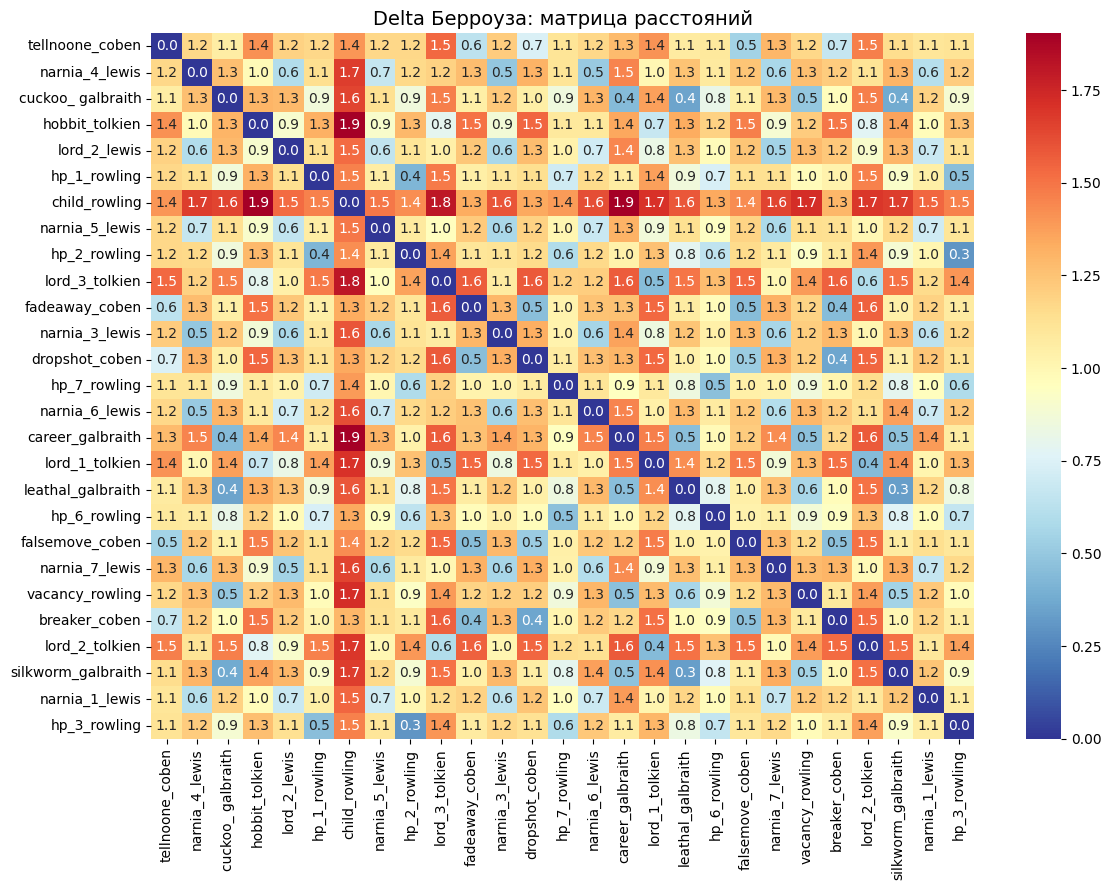

In [94]:
# Рассчитываем Delta
delta_distances = calculate_delta(freq_df)

# Визуализация матрицы расстояний
def plot_heatmap(delta_distances):
    plt.figure(figsize=(12, 9))
    sns.heatmap(delta_distances, annot=True, fmt='.1f', cmap='RdYlBu_r')
    plt.title('Delta Берроуза: матрица расстояний', fontsize=14)
    plt.tight_layout()
    plt.show()
    
plot_heatmap(delta_distances)

In [96]:
# Находим ближайшие тексты
# Число — это расстояние
def closest_texts(texts):
    for i, name in enumerate(texts):
        distances = delta_distances.iloc[i].sort_values()
        print(f"\nБлижайшие к {name}:")
        for j, dist in distances.iloc[1:6].items():
            print(f"  {j}: {dist:.2f}")
closest_texts(texts)


Ближайшие к tellnoone_coben:
  falsemove_coben: 0.55
  fadeaway_coben: 0.63
  breaker_coben: 0.67
  dropshot_coben: 0.74
  cuckoo_ galbraith: 1.06

Ближайшие к narnia_4_lewis:
  narnia_3_lewis: 0.50
  narnia_6_lewis: 0.51
  narnia_7_lewis: 0.57
  lord_2_lewis: 0.60
  narnia_1_lewis: 0.61

Ближайшие к cuckoo_ galbraith:
  leathal_galbraith: 0.35
  silkworm_galbraith: 0.37
  career_galbraith: 0.44
  vacancy_rowling: 0.49
  hp_6_rowling: 0.81

Ближайшие к hobbit_tolkien:
  lord_1_tolkien: 0.67
  lord_2_tolkien: 0.78
  lord_3_tolkien: 0.79
  narnia_3_lewis: 0.88
  narnia_7_lewis: 0.89

Ближайшие к lord_2_lewis:
  narnia_7_lewis: 0.55
  narnia_3_lewis: 0.57
  narnia_4_lewis: 0.60
  narnia_5_lewis: 0.65
  narnia_1_lewis: 0.68

Ближайшие к hp_1_rowling:
  hp_2_rowling: 0.42
  hp_3_rowling: 0.45
  hp_7_rowling: 0.71
  hp_6_rowling: 0.73
  leathal_galbraith: 0.86

Ближайшие к child_rowling:
  breaker_coben: 1.30
  fadeaway_coben: 1.34
  hp_6_rowling: 1.34
  dropshot_coben: 1.34
  hp_7_rowling:

Как можно заметить, авторы в основном ближе всего к самим себе, что ожидаемо. 

Теперь проведём **агломеративную иерархическую кластеризацию** матрицы расстояний и отразим близость между документами на **дендрограмме** - классическом способе визуализации при решении стилометрических задач.

> Как устроена иерархическая кластеризация?

Каждый текст — отдельный кластер (всего 5 кластеров). Находим два самых близких текста и объединяем их в один кластер. Пересчитываем расстояния от нового кластера до всех остальных (способ пересчёта зависит от метода linkage — об этом ниже). Повторяем, пока не останется один кластер.

In [ ]:
def cluster_texts(delta_matrix):
    """
    Кластеризует тексты
    
    Параметры:
    delta_matrix: матрица расстояний Delta
    """
    # Преобразуем матрицу расстояний в форму, пригодную для кластерного анализа
    # Извлекаем верхний треугольник матрицы
    distances = squareform(delta_matrix.values)

    # Квадратная матрица (n x n):
    # [[0 1 2 3]
    #  [1 0 4 5]
    #  [2 4 0 6]
    #  [3 5 6 0]]

    # Компактный вектор:
    # [1 2 3 4 5 6]
    
    # Выполняем кластерный анализ (метод Ward минимизирует внутрикластерную дисперсию, 
    # т.е. объединяет те кластеры, при слиянии которых рост суммы квадратов отклонений минимален)
    linkage_matrix = linkage(distances, method='ward')

    return linkage_matrix
    

linkage_matrix = cluster_texts(delta_distances)
linkage_matrix

array([[ 8.        , 26.        ,  0.30093925,  2.        ],
       [17.        , 24.        ,  0.32943485,  2.        ],
       [12.        , 22.        ,  0.35935046,  2.        ],
       [ 2.        , 28.        ,  0.37391715,  3.        ],
       [16.        , 23.        ,  0.44235161,  2.        ],
       [10.        , 19.        ,  0.45206761,  2.        ],
       [15.        , 21.        ,  0.46219501,  2.        ],
       [13.        , 18.        ,  0.46439056,  2.        ],
       [ 5.        , 27.        ,  0.47362748,  3.        ],
       [ 1.        , 11.        ,  0.49739439,  2.        ],
       [29.        , 32.        ,  0.53019789,  4.        ],
       [14.        , 36.        ,  0.54366723,  3.        ],
       [ 4.        , 20.        ,  0.54836811,  2.        ],
       [ 9.        , 31.        ,  0.55786441,  3.        ],
       [30.        , 33.        ,  0.60733373,  5.        ],
       [ 7.        , 39.        ,  0.63064749,  3.        ],
       [25.        , 38.

Что хранится в матрице?

[ 8.        , 26.        ,  0.30093925,  2.        ]

Объединяются кластеры 8 и 26, расстояние между ними -- 0.3, в кластере 2 документа. 
В данном случае под кластерами 8 и 26 понимаются тексты 8 и 26. Созданный кластер имеет индекс 28, потому что текстов всего 27.

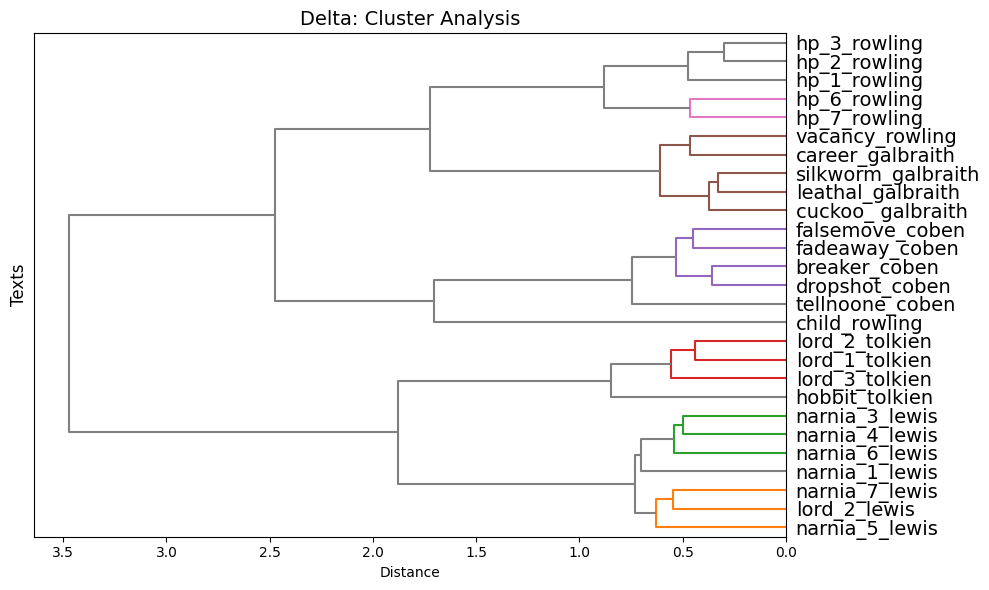

In [98]:
def plot_dendrogram(linkage_matrix, delta_matrix, title, color_threshold=0.7):
    '''Рисует дендрограмму'''
    plt.figure(figsize=(10, 6))
    dendrogram(
        linkage_matrix,
        labels=delta_matrix.index,
        orientation='left',
        leaf_font_size=14,
        leaf_rotation=0,
        color_threshold=color_threshold,
        above_threshold_color='gray'
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Distance', fontsize=10)
    plt.ylabel('Texts', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_dendrogram(linkage_matrix, delta_distances, title="Delta: Cluster Analysis")

### ROLLING DELTA

### Применение Delta для текстов, написанных в соавторстве: кто автор фрагмента?

Возьмём [датасет](https://github.com/dhhse/distantreading/blob/main/stylometry/stylometry_texts/rollingclassify.zip) с текстами Ильфа и Петрова. Определим наиболее вероятного автора каждого из фрагментов романа "Одноэтажная Америка", написанного в соавторстве. [Тут](https://cyberleninka.ru/article/n/odnoetazhnaya-amerika-ilfpetrova-dva-pocherka-odnogo-pisatelya) можно прочитать статью про решение этого же вопроса качественными методами.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict

def load_texts_by_author(folder_path):
    """Загружает тексты и сразу склеивает по авторам"""
    authors_texts = defaultdict(str) 
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            with open(os.path.join(folder_path, filename), 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
                author = filename.split('_')[0].lower()
                # Склеиваем тексты одного автора
                authors_texts[author] += " " + text
    return authors_texts

def preprocess_ru(text):
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^А-Яа-я\s\-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

def preprocess_all_texts(texts_dict):
    """Очищаем все тексты в словаре"""
    for author in texts_dict:
        texts_dict[author] = preprocess_ru(texts_dict[author])
    return texts_dict

ref_texts = load_texts_by_author("rollingclassify/reference_set")
ref_texts = preprocess_all_texts(ref_texts)
test_text = list(load_texts_by_author("rollingclassify/test_set").values())[0]
test_text = preprocess_ru(test_text)
ref_texts

defaultdict(str,
            {'petrov': 'е петров в фашистской германии из путевых записок собрание сочинений том государственное издательство художественной литературы москва кудрявцев гг незадолго до вероломного нападения фашистов на советский союз мне привелось побывать в германии уже в вагоне немецкого поезда стало ясно что германия совсем не похожа на ту которую я видел и знал до прихода гитлеровцев к власти от спального вагона митропа когда-то они были образцом чистоты и комфорта осталось одно лишь роскошное название потолки купе и коридора превратились из белых в какие-то бурые обшарпанные полированное дерево мебели было в царапинах пол грязноват от двери купе отстала длинная металлическая полоска и больно царапала тех кто имел неосторожность к ней приблизиться проводник покачал головой потрогал полоску пальцем сделал неудачную попытку справиться с ней при помощи перочинного ножа потом махнул рукой все равно в заключение проводник обсчитал нас на несколько марок -- случай которы

In [ ]:
def create_author_profiles(authors_texts, max_features=100):
    """Создаем профили авторов"""
    
    vectorizer = CountVectorizer(max_features=max_features)
    
    freq_matrix = vectorizer.fit_transform(authors_texts.values())
    dense_matrix = freq_matrix.toarray()
    author_df = pd.DataFrame(dense_matrix,
        index=authors_texts.keys(),
        columns=vectorizer.get_feature_names_out())
    
    author_df = author_df.astype(float) #потому что будем нормализовывать
    # делим на кол-во слов в тексте
    total_words = {name: len(text.split()) for name, text in authors_texts.items()}
    
    for name in author_df.index:
        author_df.loc[name] = author_df.loc[name] / total_words[name]
    
    return author_df

authors_df = create_author_profiles(ref_texts)
authors_df

,без,больше,будет,бы,был,была,были,было,быть,вам,...,человек,чем,через,что,чтобы,эти,это,этого,этом,этот
petrov,0.000808,0.000716,0.001120,0.002309,0.002828,0.001351,0.001639,0.003809,0.001085,0.000912,...,0.001535,0.00090,0.000854,0.012767,0.001062,0.000820,0.006972,0.000854,0.000889,0.000854
ilf,0.000798,0.000929,0.001043,0.001515,0.002184,0.001499,0.000994,0.002982,0.000961,0.000896,...,0.001776,0.00088,0.000896,0.010136,0.000961,0.000717,0.005964,0.001157,0.000570,0.000896


In [ ]:
def delta_for_window(window_text, authors_df):
    """Вычисляем Delta между окном и профилями авторов"""
    # векторизуем окно тем же векторизатором
    all_words = authors_df.columns.tolist()
    vectorizer = CountVectorizer(vocabulary=all_words)
    window_freq = vectorizer.transform([window_text]) 
    window_df = pd.DataFrame(window_freq.toarray(), columns=all_words)
    
    # нормализуем частотности на длину окна
    window_df = window_df / len(window_text.split()) 
    # склеиваем в один датафрейм
    combined = pd.concat([authors_df, window_df], axis=0)
    
    # считаем Z-scores
    std_values = combined.std().replace(0, 0.1)
    z_scores = (combined - combined.mean()) / std_values
    
    # Delta для каждого автора
    window_z = z_scores.iloc[-1:]
    deltas = {}
    for author in authors_df.index:
        author_z = z_scores.loc[author]
        deltas[author] = np.sum(np.abs(window_z.values[0] - author_z.values)) / len(all_words)
    
    return deltas

In [147]:
def rolling_delta(text, author_profile_df, window_size=5000, step=5000):
 
    words = text.split()
    n_words = len(words)
    results = []
    n_windows = (n_words - window_size) // step + 1
    
    for i in range(n_windows):
        start = i * step
        end = start + window_size
        window = ' '.join(words[start:end])
        
        deltas = delta_for_window(window, author_profile_df)
        closest_author = min(deltas, key=deltas.get)
        min_delta = deltas[closest_author]
        
        results.append({
            'window': i + 1,
            'position': end,
            'closest_author': closest_author,
            'min_delta': min_delta
        })
        
    return pd.DataFrame(results)

deltas_df = rolling_delta(test_text, authors_df)
deltas_df

,window,position,closest_author,min_delta
0,1,5000,ilf,1.366848
1,2,10000,ilf,1.367994
2,3,15000,ilf,1.393994
3,4,20000,ilf,1.315510
4,5,25000,ilf,1.388734
5,6,30000,ilf,1.367228
6,7,35000,ilf,1.384083
7,8,40000,petrov,1.326343
8,9,45000,petrov,1.377689
9,10,50000,ilf,1.339791


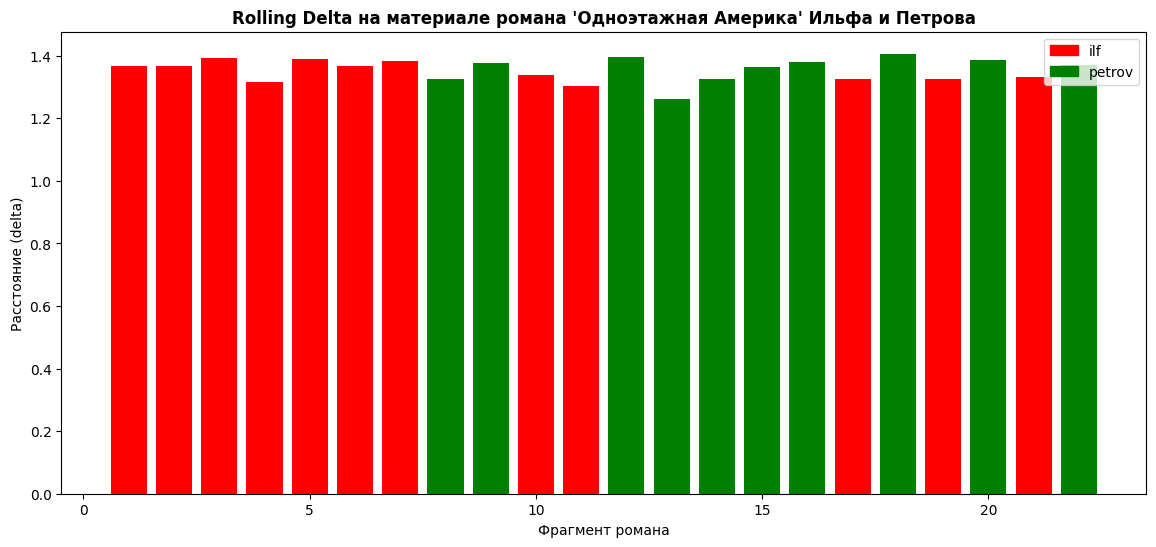

In [149]:
def plot_rolling_delta(results_df, title="Rolling Delta на материале романа 'Одноэтажная Америка' Ильфа и Петрова"):

    color_map = {'ilf': 'red', 'petrov': 'green'}
    colors = [color_map[a] for a in results_df['closest_author']]

    plt.figure(figsize=(14, 6))
    
    plt.bar(range(1, len(results_df) + 1), 
                   results_df['min_delta'],
                   color=colors)
    

    plt.xlabel('Фрагмент романа')
    plt.ylabel('Расстояние (delta)')
    plt.title(title, fontweight='bold')
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=color, label=author) 
                       for author, color in color_map.items()]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

plot_rolling_delta(deltas_df)

Отлично, но есть нюанс: мы определяем наиболее вероятного автора бинарно и независимо от того, насколько мы уверены в выборе. Исправим это и зададим порог для разницы между расстояниями от окна до каждого из текстов. При недостижении порога укажем на графике, что различия между авторскими сигналами не значимы.

In [159]:
def rolling_delta(text, author_profile_df, window_size=5000, step=5000):
 
    words = text.split()
    n_words = len(words)
    results = []
    n_windows = (n_words - window_size) // step + 1
    
    for i in range(n_windows):
        start = i * step
        end = start + window_size
        window = ' '.join(words[start:end])
        
        deltas = delta_for_window(window, author_profile_df)
        closest_author = min(deltas, key=deltas.get)
        min_delta = deltas[closest_author]
        
        results.append({
            'window': i + 1,
            'position': end,
            'closest_author': closest_author,
            'min_delta': min_delta,
            **deltas
        })
        
    return pd.DataFrame(results)

deltas_df = rolling_delta(test_text, authors_df)
deltas_df

,window,position,closest_author,min_delta,petrov,ilf
0,1,5000,ilf,1.366848,1.489536,1.366848
1,2,10000,ilf,1.367994,1.474517,1.367994
2,3,15000,ilf,1.393994,1.425209,1.393994
3,4,20000,ilf,1.315510,1.510890,1.315510
4,5,25000,ilf,1.388734,1.483159,1.388734
5,6,30000,ilf,1.367228,1.398824,1.367228
6,7,35000,ilf,1.384083,1.427563,1.384083
7,8,40000,petrov,1.326343,1.326343,1.465709
8,9,45000,petrov,1.377689,1.377689,1.394719
9,10,50000,ilf,1.339791,1.507144,1.339791


Посчитаем порог (пусть это будет стандартное отклонение).

In [ ]:
for idx, row in deltas_df.iterrows():
    deltas_df.loc[idx, "abs_diff"] = np.abs(deltas_df.loc[idx, "ilf"] - deltas_df.loc[idx, "petrov"])

std_abs = deltas_df['abs_diff'].std()
print(std_abs)

0.057907269372209046


In [171]:
for idx, row in deltas_df.iterrows():
    if np.abs(row["ilf"] - row["petrov"]) < std_abs:
        deltas_df.loc[idx, "closest_author"] = "unknown"
        deltas_df.loc[idx, "min_delta"] = (row["ilf"] + row["petrov"]) / 2

deltas_df

,window,position,closest_author,min_delta,petrov,ilf,abs_diff
0,1,5000,ilf,1.366848,1.489536,1.366848,0.122688
1,2,10000,ilf,1.367994,1.474517,1.367994,0.106523
2,3,15000,unknown,1.409602,1.425209,1.393994,0.031215
3,4,20000,ilf,1.315510,1.510890,1.315510,0.195379
4,5,25000,unknown,1.435946,1.483159,1.388734,0.094426
5,6,30000,unknown,1.383026,1.398824,1.367228,0.031596
6,7,35000,unknown,1.405823,1.427563,1.384083,0.043480
7,8,40000,petrov,1.326343,1.326343,1.465709,0.139367
8,9,45000,unknown,1.386204,1.377689,1.394719,0.017030
9,10,50000,ilf,1.339791,1.507144,1.339791,0.167352


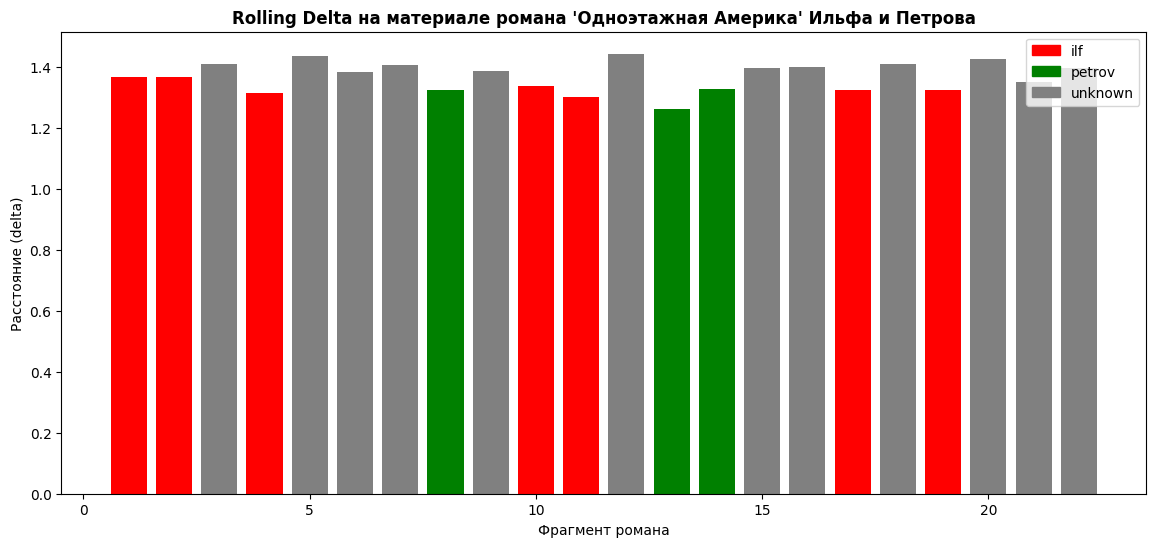

In [172]:
def plot_rolling_delta(results_df, title="Rolling Delta на материале романа 'Одноэтажная Америка' Ильфа и Петрова"):

    color_map = {'ilf': 'red', 'petrov': 'green', 'unknown': 'gray'}
    colors = [color_map[a] for a in results_df['closest_author']]

    plt.figure(figsize=(14, 6))
    
    plt.bar(range(1, len(results_df) + 1), 
                   results_df['min_delta'],
                   color=colors)
    

    plt.xlabel('Фрагмент романа')
    plt.ylabel('Расстояние (delta)')
    plt.title(title, fontweight='bold')
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=color, label=author) 
                       for author, color in color_map.items()]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

plot_rolling_delta(deltas_df)